# Phân tích Training Loss và Hiện tượng Overfitting

Notebook này so sánh giá trị hàm mất mát (loss) trong quá trình huấn luyện giữa các mô hình để chứng minh hiện tượng Overfitting ở các phiên bản NRAGLS gốc.

Đã lưu ảnh biểu đồ thành công tại: 03_results/figures/training_loss.png


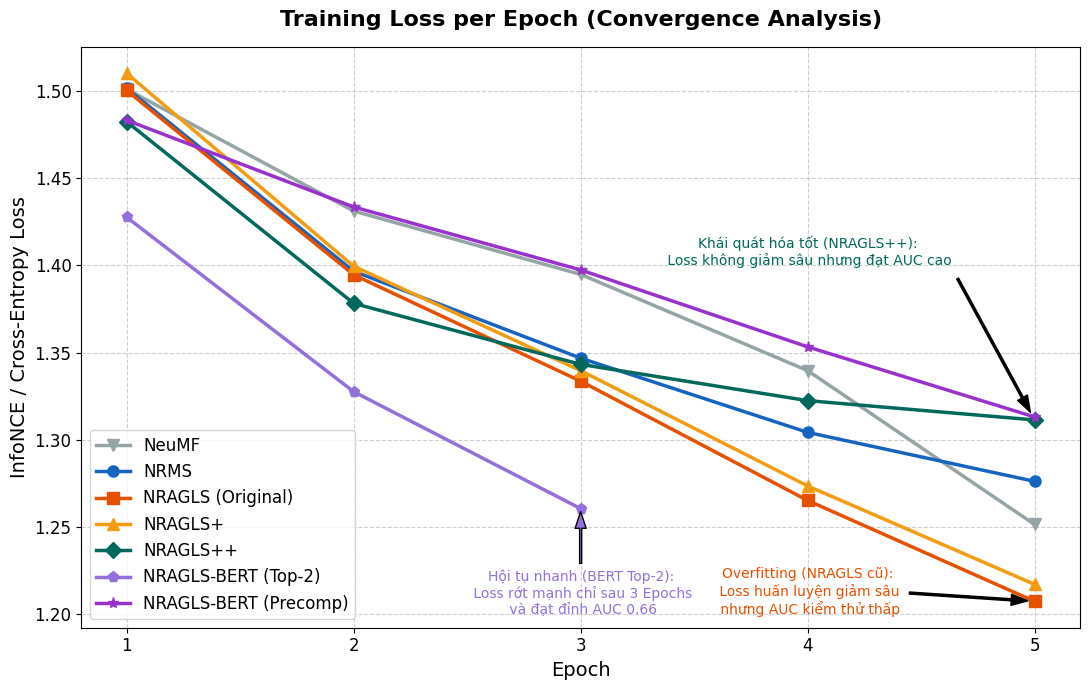

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import os

loss_data = {
    'NeuMF': [1.50082, 1.43103, 1.39474, 1.33963, 1.25150],
    'NRMS': [1.50133, 1.39656, 1.34677, 1.30426, 1.27620],
    'NRAGLS (Original)': [1.50008, 1.39450, 1.33358, 1.26526, 1.20749],
    'NRAGLS+': [1.50996, 1.39942, 1.33964, 1.27357, 1.21720],
    'NRAGLS++': [1.48221, 1.37815, 1.34321, 1.32244, 1.31138],
    'NRAGLS-BERT (Top-2)': [1.42748, 1.32757, 1.26059],
    'NRAGLS-BERT (Precomp)': [1.48304, 1.43337, 1.39731, 1.35325, 1.31306]
}

colors = {
    'NeuMF': '#95a5a6',
    'NRMS': '#1565C0',
    'NRAGLS (Original)': '#E65100',
    'NRAGLS+': '#F39C12',
    'NRAGLS++': '#00695C',
    'NRAGLS-BERT (Top-2)': '#9370DB',
    'NRAGLS-BERT (Precomp)': '#9932CC'
}

markers = {
    'NeuMF': 'v',
    'NRMS': 'o',
    'NRAGLS (Original)': 's',
    'NRAGLS+': '^',
    'NRAGLS++': 'D',
    'NRAGLS-BERT (Top-2)': 'p',
    'NRAGLS-BERT (Precomp)': '*'
}

plt.figure(figsize=(11, 7))

for model, losses in loss_data.items():
    plt.plot(range(1, len(losses) + 1), losses, marker=markers[model], color=colors[model], 
             linewidth=2.5, markersize=8, label=model)

plt.title('Training Loss per Epoch (Convergence Analysis)', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('InfoNCE / Cross-Entropy Loss', fontsize=14)
plt.xticks(range(1, 6), fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, loc='lower left')

plt.annotate('Overfitting (NRAGLS cũ):\n Loss huấn luyện giảm sâu\n nhưng AUC kiểm thử thấp', 
             xy=(5, 1.20749), xytext=(4, 1.20),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=10, color='#E65100', ha='center')

plt.annotate('Khái quát hóa tốt (NRAGLS++):\n Loss không giảm sâu nhưng đạt AUC cao', 
             xy=(5, 1.31138), xytext=(4, 1.40),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=10, color='#00695C', ha='center')

plt.annotate('Hội tụ nhanh (BERT Top-2):\n Loss rớt mạnh chỉ sau 3 Epochs\n và đạt đỉnh AUC 0.66', 
             xy=(3, 1.26059), xytext=(3.0, 1.20),
             arrowprops=dict(facecolor='#9370DB', shrink=0.05, width=1.5, headwidth=8),
             fontsize=10, color='#9370DB', ha='center')

plt.tight_layout()

os.makedirs('03_results/figures', exist_ok=True)
save_path = '03_results/figures/training_loss.png'
plt.savefig(save_path, dpi=300)
print(f'Đã lưu ảnh biểu đồ thành công tại: {save_path}')
plt.show()
